In [1]:
import pandas as pd

In [39]:
#Step 1: Load and Explore

#Reading the spotify csv data
df = pd.read_csv("data.csv")

#Displays the first 5 rows
df.head()

#Displays information about the number of rows(how many songs?), columns, what data-type each column is, are there any null/missing values?
df.info()

#Gives the summary statistics for every numeric column
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
count,170653.000000,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.528587,1976.787241,0.502115,0.537396,2.309483e+05,0.482389,0.084575,0.167010,5.199844,0.205839,-11.467990,0.706902,31.431794,0.098393,116.861590
std,0.263171,25.917853,0.376032,0.176138,1.261184e+05,0.267646,0.278249,0.313475,3.515094,0.174805,5.697943,0.455184,21.826615,0.162740,30.708533
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000
25%,0.317000,1956.000000,0.102000,0.415000,1.698270e+05,0.255000,0.000000,0.000000,2.000000,0.098800,-14.615000,0.000000,11.000000,0.034900,93.421000
50%,0.540000,1977.000000,0.516000,0.548000,2.074670e+05,0.471000,0.000000,0.000216,5.000000,0.136000,-10.580000,1.000000,33.000000,0.045000,114.729000
75%,0.747000,1999.000000,0.893000,0.668000,2.624000e+05,0.703000,0.000000,0.102000,8.000000,0.261000,-7.183000,1.000000,48.000000,0.075600,135.537000
max,1.000000,2020.000000,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,11.000000,1.000000,3.855000,1.000000,100.000000,0.970000,243.507000


Valence measures how positive or happy a song sounds.

**Interpretation:**

Looking at the dataset, we can see that it contains 170,653 songs and 19 columns. Based on the information displayed in df.info(), the columns do not appear to have any missing values since their counts are all 170,653. The dataset contains a mix of float, integer, and object data types. Looking at some summary statistics, the average song has a valence score of 0.53, suggesting that songs are generally neither extremely happy nor extremely sad. The average danceability score is also around 0.54, indicating that songs are moderately danceable. Similarly, the average energy score is about 0.48, suggesting a moderate level of intensity rather than being extremely calm or highly energetic.

In [21]:
#Step 2: Data Cleaning

#Check NULL values
#df.isnull().sum()

#df.duplicated() checks each row and returns either True or False depending on whether that row is a duplicate.
df.duplicated().sum()

#df.drop_duplicates() removes duplicate rows. By default, it keeps the first occurrence and removes the later occurrences, but only if the rows are identical across
#all columns being checked. inplace = True: Make the change directly to the original dataframe instead of creating a new one.
df.drop_duplicates(inplace=True)

The dataset has 0 NULL values no duplicate values.

In [43]:
#Investigate why the same song by the same artist appears multiple times.
duplicate_songs = df[df.duplicated(subset=["name","artists"],keep=False)]
duplicate_songs.sort_values(["name", "artists"]).head(10)

#Subset: Only use these columns when deciding whether something is duplicated.
#keep=False: Mark every occurrence of a duplicated song as True, including the first one.

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
67836,0.3100,1983,0.18500,['U2'],0.371,157667,0.545,0,6DdWA7D1o5TU2kXWyCLcch,0.58200,8,0.1830,-9.315,1,"""40"" - Remastered 2008",36,28-02-1983,0.0307,150.316
85098,0.3100,1983,0.18500,['U2'],0.371,157667,0.545,0,3vMmwsAiLDCfyc1jl76lQE,0.58200,8,0.1830,-9.315,1,"""40"" - Remastered 2008",35,28-02-1983,0.0307,150.316
21701,0.3300,1934,0.94100,"['Georges Bizet', 'Jascha Heifetz', 'Donald Vo...",0.385,570920,0.193,0,5AZvNKWS9yPpXntKqHAhYw,0.43300,2,0.4150,-20.298,1,"""Carmen Fantasie"", by Franz Waxman, based on t...",2,1934,0.0457,131.083
24090,0.3420,1946,0.94300,"['Georges Bizet', 'Jascha Heifetz', 'Donald Vo...",0.289,583573,0.198,0,0xVbtHC4BM071oCAYrMxy1,0.37600,9,0.1940,-19.978,1,"""Carmen Fantasie"", by Franz Waxman, based on t...",0,1946,0.0539,70.255
54622,0.6700,2007,0.00614,['Fall Out Boy'],0.609,213587,0.917,0,3rG8ZkmKHb4Ms6CsSzEITv,0.00002,9,0.0775,-2.563,1,"""The Take Over, The Breaks Over""",58,01-01-2007,0.0477,149.948
89666,0.6700,2007,0.00614,['Fall Out Boy'],0.609,213587,0.917,0,4zCfMDdf5QXPKEqxdinXvB,0.00002,9,0.0775,-2.563,1,"""The Take Over, The Breaks Over""",52,06-02-2007,0.0477,149.948
18729,0.0477,2015,0.00538,"['$uicideBoy$', 'Pouya']",0.797,169320,0.516,1,4VsMart0lkjUtyQnmxloK6,0.43100,1,0.0728,-6.286,1,$outh $ide $uicide,71,15-06-2015,0.0831,109.997
154608,0.0524,2015,0.00591,"['$uicideBoy$', 'Pouya']",0.798,169169,0.529,1,5NXeprz7VhJkG6RgSAqqeO,0.39400,1,0.0720,-6.327,1,$outh $ide $uicide,53,01-09-2015,0.0740,109.995
74562,0.3460,2017,0.21300,"['Billie Eilish', 'Vince Staples']",0.776,179016,0.379,0,7uX3gufAoBVqKVoD3dBLLD,0.00175,9,0.0969,-9.351,0,&burn (with Vince Staples),68,15-12-2017,0.3310,82.531
124296,0.3460,2017,0.21300,"['Billie Eilish', 'Vince Staples']",0.776,179016,0.379,0,6X7qcg95CAeJpTjtg1wooM,0.00175,9,0.0969,-9.351,0,&burn (with Vince Staples),63,22-12-2017,0.3310,82.531


Several songs by the same artist appear multiple times with different values in other columns. Since these records are not exact duplicates, they were retained. The differences may represent separate versions of the same song, releases across different years, or distinct observations captured in the dataset. **Additional metadata would be required to determine the exact reason.**

In [22]:
df["popularity"].describe()

,popularity
count,170653.000000
mean,31.431794
std,21.826615
min,0.000000
25%,11.000000
50%,33.000000
75%,48.000000
max,100.000000


In [26]:
df["popularity"].value_counts().sort_index()

# .value_count() counts how many times each value appears. By default, value_counts() sorts by frequency, highest first.
# sort_index() sorts results by the index values

,count
popularity,
0,27892
1,2876
2,1733
3,1467
4,1114
...,...
95,4
96,4
97,1


In [27]:
#Step 3: Exploratory Data Analysis

Question 1: What does song popularity look like overall?

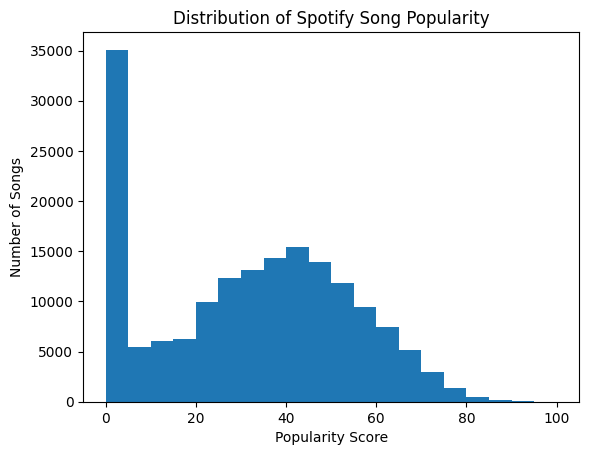

In [28]:
import matplotlib.pyplot as plt

plt.hist(df["popularity"],bins=20) #bins = 20 : Divide the popularity values into approximately 20 ranges.
plt.xlabel("Popularity Score")
plt.ylabel("Number of Songs")
plt.title("Distribution of Spotify Song Popularity")

plt.show()

Question 2: Which songs are the most popular?

In [31]:
df.nlargest(10,"popularity")[["name","artists","popularity"]]

# .nlargest(): Display the top 10 rows with the highest popularity values.
# ["name","artists","popularity"]: From the top 10 rows, only display the following columns

,name,artists,popularity
19611,Dakiti,"['Bad Bunny', 'Jhay Cortez']",100
19606,Mood (feat. iann dior),"['24kGoldn', 'iann dior']",99
19618,Dynamite,['BTS'],97
19608,WAP (feat. Megan Thee Stallion),"['Cardi B', 'Megan Thee Stallion']",96
19610,positions,['Ariana Grande'],96
19612,What You Know Bout Love,['Pop Smoke'],96
19616,Blinding Lights,['The Weeknd'],96
19607,For The Night (feat. Lil Baby & DaBaby),"['Pop Smoke', 'Lil Baby', 'DaBaby']",95
19615,Holy (feat. Chance The Rapper),"['Justin Bieber', 'Chance the Rapper']",95
19620,Lonely (with benny blanco),"['Justin Bieber', 'benny blanco']",95


Question 3: Which artists are the most popular?

In [38]:
artist_summary = df.groupby("artists").agg(avg_popularity=("popularity","mean"),song_count=("name","count"))

display(artist_summary[artist_summary["song_count"]>=5].nlargest(10,"avg_popularity"))

,avg_popularity,song_count
artists,,
['Ava Max'],78.714286,7
['Harry Styles'],78.346154,26
['Billie Eilish'],78.250000,32
['Pop Smoke'],76.538462,13
['Maluma'],76.222222,9
['BLACKPINK'],75.866667,15
['CORPSE'],75.333333,6
['Tate McRae'],75.142857,7
['Arizona Zervas'],75.000000,5


In [44]:
df["popularity"].describe()

,popularity
count,170653.000000
mean,31.431794
std,21.826615
min,0.000000
25%,11.000000
50%,33.000000
75%,48.000000
max,100.000000


1. The average popularity score is approximately 31.43. This suggests that songs in the dataset generally have relatively low popularity scores.

2. The median (50th percentile) popularity score is 33. This means that 50% of songs have a popularity score of 33 or less, while the other 50% have a popularity score above 33.

3. The 75th percentile popularity score is 48. This means that 75% of songs have a popularity score of 48 or less, and only 25% of songs have a popularity score greater than 48.

The average popularity score in the dataset is 31.4, with a median of 33. This indicates that most songs have relatively low popularity scores. Additionally, 75% of songs have popularity scores below 48, suggesting that highly popular tracks represent a relatively small portion of the dataset. Therefore, songs with popularity scores above 70 can reasonably be considered highly popular within this sample.

In [45]:
#Correlation

features = [
    "popularity",
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "tempo",
    "loudness"
]

df[features].corr()["popularity"].sort_values(ascending=False)

,popularity
popularity,1.000000
energy,0.485005
loudness,0.457051
danceability,0.199606
tempo,0.133310
valence,0.014200
liveness,-0.076464
speechiness,-0.171979
instrumentalness,-0.296750
acousticness,-0.573162


First, we create a list of the features we want to analyze. Next, df[features] selects only those columns from the DataFrame. The corr() function then calculates the correlation between every pair of selected features and returns a correlation matrix. By selecting ["popularity"], we extract only the correlations involving popularity. Finally, sort_values(ascending=False) sorts those correlations from highest to lowest so we can quickly identify which features have the strongest positive and negative relationships with popularity.

1. Acousticness has the strongest relationship with popularity. The relationship is negative, meaning songs with higher acousticness tend to have lower popularity scores, while songs with lower acousticness tend to have higher popularity scores.

2. More energetic songs tend to be more popular.

3. Louder songs also tend to be more popular.

4. More danceable songs tend to be slightly more popular, but the relationship is not very strong.

5. Faster songs (higher tempo) tend to be slightly more popular, but tempo alone doesn't appear to be a major driver of popularity.

6. Whether a song sounds happy or sad does not appear to have a meaningful relationship with popularity in this dataset.

7. Songs with more spoken-word content tend to be slightly less popular.

8. Songs that sound more like live recordings tend to be slightly less popular.

The strongest relationships with popularity are associated with acousticness, energy, and loudness. Popular songs in this dataset tend to be less acoustic, more energetic, and louder than less popular songs.


In [47]:
import numpy as np

df["popularity_group"] = np.where(df["popularity"]>=70,"Popular", "Not Popular")

display(df["popularity_group"].value_counts())

,count
popularity_group,
Not Popular,165638
Popular,5015


In [49]:
df.groupby("popularity_group")[["popularity",
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "instrumentalness",
    "speechiness",
    "liveness",
    "tempo",
    "loudness"]].mean()

,popularity,danceability,energy,valence,acousticness,instrumentalness,speechiness,liveness,tempo,loudness
popularity_group,,,,,,,,,,
Not Popular,30.121192,0.534146,0.477852,0.529295,0.510008,0.171298,0.098299,0.206796,116.734039,-11.606286
Popular,74.719043,0.644712,0.632220,0.505215,0.241428,0.025367,0.101518,0.174234,121.074395,-6.900264


Only about 3% of songs in the dataset have a popularity score of 70 or higher.

Popular songs differ noticeably from the rest of the dataset. Songs with popularity scores of 70 or higher tend to be more danceable, more energetic, and louder. They also have significantly lower acousticness and instrumentalness scores, suggesting that highly popular songs are generally less acoustic and less instrumental. In contrast, valence and tempo show relatively small differences between the two groups, indicating that a song's emotional tone and speed may play a smaller role in popularity.

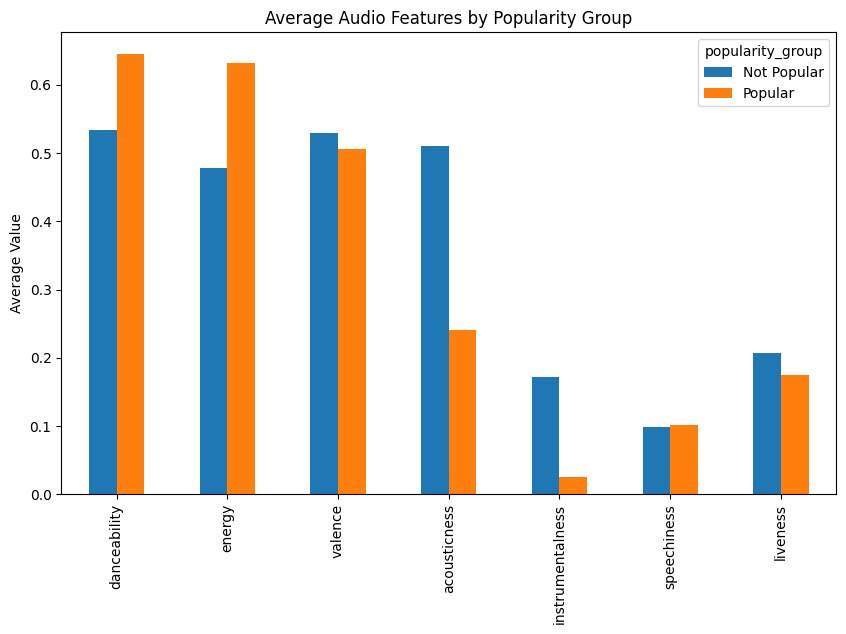

In [53]:
comparison = df.groupby("popularity_group")[
    ["danceability","energy","valence","acousticness","instrumentalness","speechiness", "liveness"]].mean()

comparison.T.plot(kind="bar", figsize=(10,6))

plt.title("Average Audio Features by Popularity Group")
plt.ylabel("Average Value")

plt.show()